<a href="https://colab.research.google.com/github/Rendhazuper/PCVK_Genap_2025/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


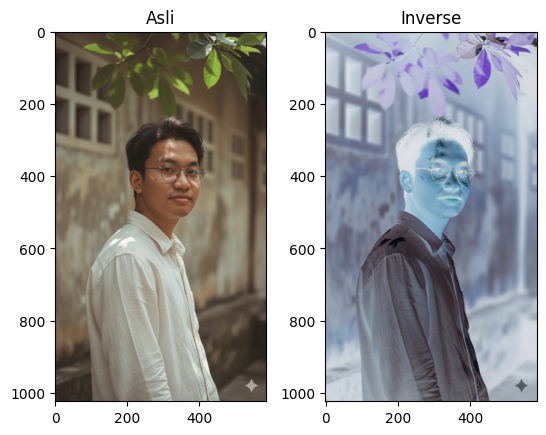

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/Content/Fotoku.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

inverse = 255 - img_rgb

plt.subplot(1,2,1), plt.imshow(img_rgb), plt.title("Asli")
plt.subplot(1,2,2), plt.imshow(inverse), plt.title("Inverse")
plt.show()

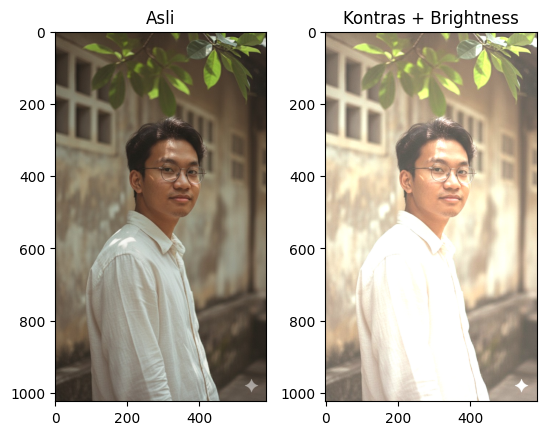

In [ ]:
import numpy as np

contrast = 50
brightness = 50

def adjust_contrast_brightness(img, contrast, brightness):
  return cv.convertScaleAbs(img, alpha=contrast/127+1, beta=brightness)

img_contrast = adjust_contrast_brightness(img_rgb, contrast, brightness)

plt.subplot(1,2,1), plt.imshow(img_rgb), plt.title("Asli")
plt.subplot(1,2,2), plt.imshow(img_contrast), plt.title("Kontras + Brightness")
plt.show()

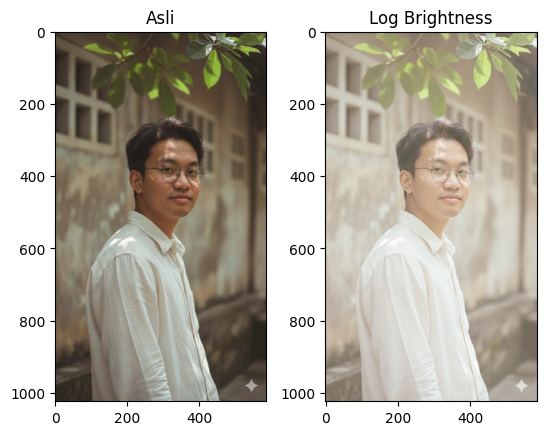

In [ ]:
c = 50

img_float = img_rgb.astype(float)
log_transformed = c * np.log1p(img_float)
log_transformed = np.uint8(cv.normalize(log_transformed, None, 0, 255, cv.NORM_MINMAX))

plt.subplot(1,2,1), plt.imshow(img_rgb), plt.title("Asli")
plt.subplot(1,2,2), plt.imshow(log_transformed), plt.title("Log Brightness")
plt.show()


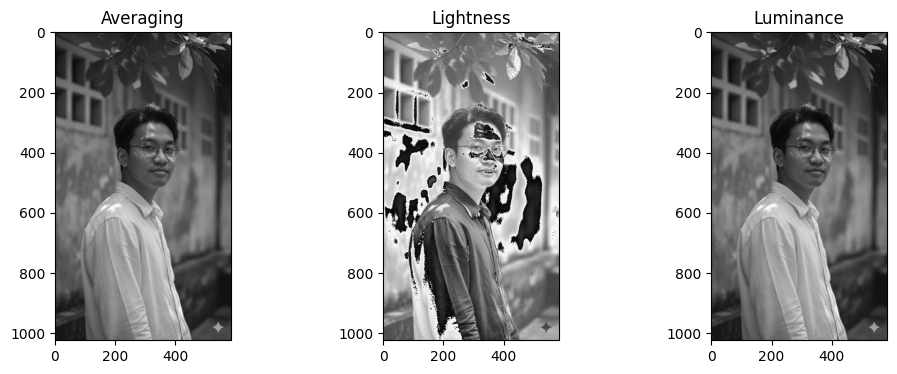

In [ ]:

gray_avg = np.mean(img_rgb, axis=2).astype(np.uint8)


gray_light = ((np.max(img_rgb, axis=2) + np.min(img_rgb, axis=2)) / 2).astype(np.uint8)


gray_lum = (0.21*img_rgb[:,:,0] + 0.72*img_rgb[:,:,1] + 0.07*img_rgb[:,:,2]).astype(np.uint8)


plt.figure(figsize=(12,4))
plt.subplot(1,3,1), plt.imshow(gray_avg, cmap='gray'), plt.title("Averaging")
plt.subplot(1,3,2), plt.imshow(gray_light, cmap='gray'), plt.title("Lightness")
plt.subplot(1,3,3), plt.imshow(gray_lum, cmap='gray'), plt.title("Luminance")
plt.show()


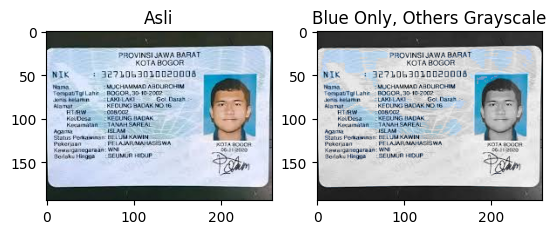

In [ ]:

img2 = cv.imread('/content/drive/MyDrive/Content/images.jpeg')
img_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

hsv = cv.cvtColor(img_rgb, cv.COLOR_RGB2HSV)

lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])

mask = cv.inRange(hsv, lower_blue, upper_blue)
color = cv.bitwise_and(img_rgb, img_rgb, mask=mask)

gray = cv.cvtColor(img_rgb, cv.COLOR_RGB2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

combined = np.where(color!=0, img_rgb, gray_bgr)

plt.subplot(1,2,1), plt.imshow(img_rgb), plt.title("Asli")
plt.subplot(1,2,2), plt.imshow(combined), plt.title("Blue Only, Others Grayscale")
plt.show()


 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3


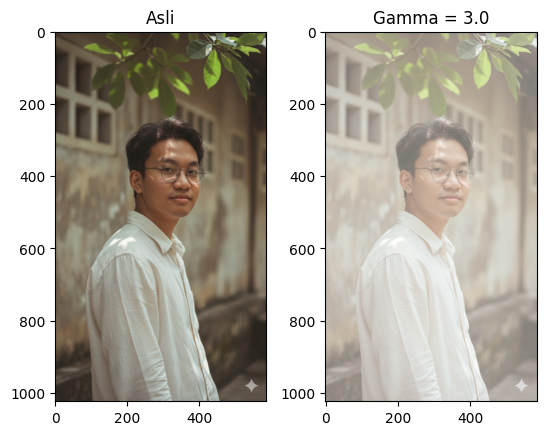

In [ ]:

print(" Gamma Correction pada citra ")
print("----------------------------------")

try:
    gamma = float(input("Masukkan nilai Gamma: "))
except ValueError:
    print("Error, not a number")


img = cv.imread('/content/drive/MyDrive/Content/Fotoku.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)


normalized = img_rgb / 255.0

gamma_corrected = np.power(normalized, 1.0/gamma)
gamma_corrected = np.uint8(gamma_corrected * 255)


plt.subplot(1,2,1), plt.imshow(img_rgb), plt.title("Asli")
plt.subplot(1,2,2), plt.imshow(gamma_corrected), plt.title(f"Gamma = {gamma}")
plt.show()

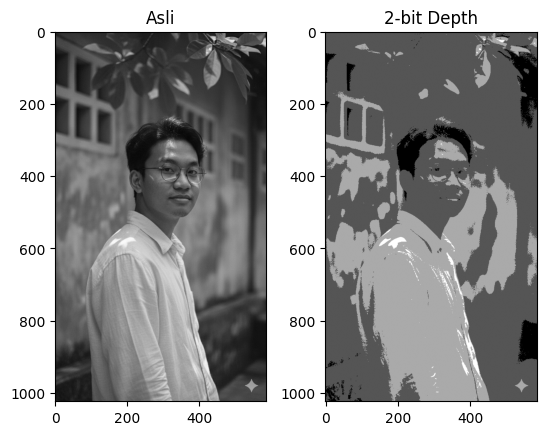

In [ ]:
bit_depth = 2
level = 255 / (pow(2, bit_depth) - 1)
original = cv.imread('/content/drive/MyDrive/Content/Fotoku.jpg', cv.IMREAD_GRAYSCALE)
depth_image = np.uint8(np.round(original / level) * level)

plt.subplot(1,2,1), plt.imshow(original, cmap='gray'), plt.title("Asli")
plt.subplot(1,2,2), plt.imshow(depth_image, cmap='gray'), plt.title(f"{bit_depth}-bit Depth")
plt.show()


PSNR 10 citra : 100
PSNR 20 citra : 100
PSNR 40 citra : 100
PSNR 80 citra : 100
PSNR 100 citra: 100


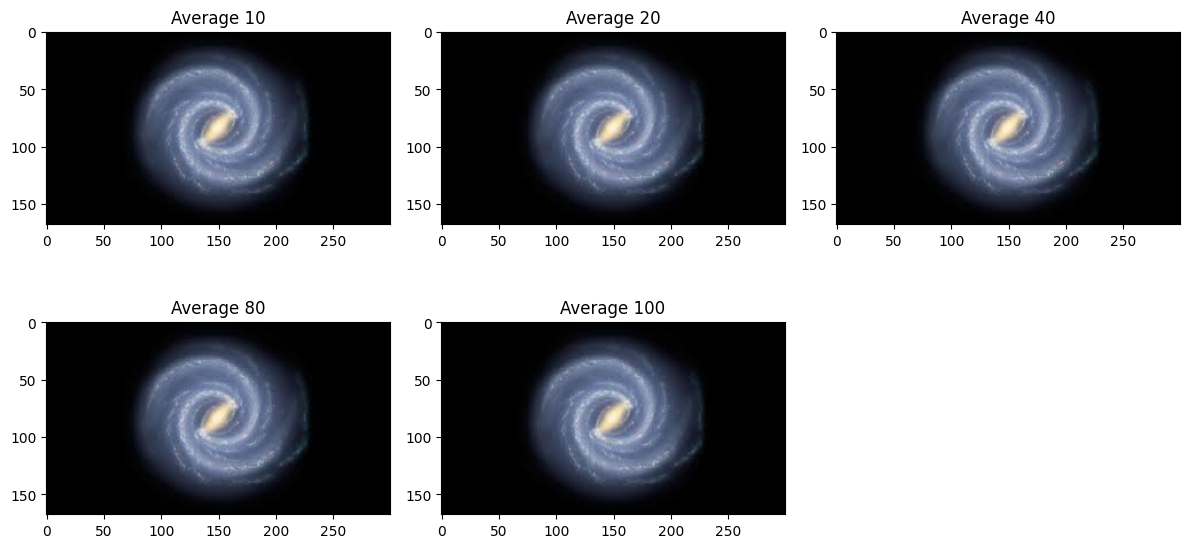

In [ ]:
import cv2 as cv
import numpy as np
import glob
import matplotlib.pyplot as plt
import math

files = sorted(glob.glob('/content/drive/MyDrive/Content/*.jpeg'))

cv_img = []
for p in files:
    im = cv.imread(p)
    if im is None:
        continue
    if im.ndim == 2:
        im = cv.cvtColor(im, cv.COLOR_GRAY2BGR)
    elif im.shape[2] == 4:
        im = cv.cvtColor(im, cv.COLOR_BGRA2BGR)
    cv_img.append(im)

h, w = cv_img[0].shape[:2]
cv_img = [cv.resize(im, (w, h), interpolation=cv.INTER_AREA) for im in cv_img]

def average_images(img_list, N):
    N = min(N, len(img_list))
    acc = np.zeros((h, w, 3), dtype=np.float32)
    for i in range(N):
        acc += img_list[i].astype(np.float32)
    return (acc / N).astype(np.uint8)

def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)
    if mse == 0:
        return 100
    return 20 * math.log10(255.0 / math.sqrt(mse))

avg10 = average_images(cv_img, 10)
avg20 = average_images(cv_img, 20)
avg40 = average_images(cv_img, 40)
avg80 = average_images(cv_img, 80)
avg100 = average_images(cv_img, 100)

original = cv.imread('/content/drive/MyDrive/Content/download.jpeg')
original = cv.resize(original, (w, h))

print("PSNR 10 citra :", PSNR(original, avg10))
print("PSNR 20 citra :", PSNR(original, avg20))
print("PSNR 40 citra :", PSNR(original, avg40))
print("PSNR 80 citra :", PSNR(original, avg80))
print("PSNR 100 citra:", PSNR(original, avg100))

plt.figure(figsize=(12,6))
plt.subplot(231), plt.imshow(cv.cvtColor(avg10, cv.COLOR_BGR2RGB)), plt.title("Average 10")
plt.subplot(232), plt.imshow(cv.cvtColor(avg20, cv.COLOR_BGR2RGB)), plt.title("Average 20")
plt.subplot(233), plt.imshow(cv.cvtColor(avg40, cv.COLOR_BGR2RGB)), plt.title("Average 40")
plt.subplot(234), plt.imshow(cv.cvtColor(avg80, cv.COLOR_BGR2RGB)), plt.title("Average 80")
plt.subplot(235), plt.imshow(cv.cvtColor(avg100, cv.COLOR_BGR2RGB)), plt.title("Average 100")
plt.tight_layout()
plt.show()
